# Working with Real Data: Import, Explore, Visualize

Welcome back! In Session 4, you created DataFrames and practiced filtering and calculated columns. Now you will load a CSV file, check what is inside, ask simple questions of the data, and make visualizations.

**Estimated time:** 45-55 minutes

By the end, you will be able to import a CSV with pandas, inspect and check a dataset, summarize and filter records, calculate changes over time, and create labeled charts with Matplotlib.

## 1. Import the tools and load a CSV (6 minutes)

A CSV (comma-separated values) file stores table-shaped data as text. `pd.read_csv()` turns it into a DataFrame. File paths are relative to the notebook's current working directory, which can vary, so this example checks the two common locations for the provided file.

In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

csv_path = Path('../data/atlantis.csv')
if not csv_path.exists():
    csv_path = Path('data/atlantis.csv')

population = pd.read_csv(csv_path)
print('Loaded:', csv_path.resolve())
population.head()



Loaded: /workspaces/codespaces-jupyter/data/atlantis.csv



,year,population
0,2000,12400
1,2001,12800
2,2002,13800
3,2003,13600
4,2004,14200


## 2. Get to know the table (7 minutes)

Start with the size and column names, then preview the beginning and end of the table. `.info()` reports data types and non-missing values; `.describe()` summarizes numeric columns. These quick checks help you decide what questions the data can answer.

In [14]:
print('Rows and columns:', population.shape)
print('Column names:', population.columns.tolist())
print('Data types:\n', population.dtypes)
population.tail()



Rows and columns: (22, 2)
Column names: ['year', 'population']
Data types:
 year          int64
population    int64
dtype: object



,year,population
17,2017,29600
18,2018,32100
19,2019,32500
20,2020,33200
21,2021,33800


In [15]:
population.info()
population.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   year        22 non-null     int64
 1   population  22 non-null     int64
dtypes: int64(2)
memory usage: 484.0 bytes



,year,population
count,22.000000,22.000000
mean,2010.500000,22418.181818
std,6.493587,7100.411548
min,2000.000000,12400.000000
25%,2005.250000,16100.000000
50%,2010.500000,21800.000000
75%,2015.750000,27750.000000
max,2021.000000,33800.000000


### Practice 1

Display the first three rows. Which columns are present, and what does one row represent?

In [16]:
population.head(3)


,year,population
0,2000,12400
1,2001,12800
2,2002,13800


## 3. Check data quality (6 minutes)

Imported data can contain missing values or repeated records. `.isna().sum()` counts missing values in each column, and `.duplicated().sum()` counts rows that are exact duplicates. A check does not automatically mean you should delete anything: first understand what a row represents and why a value may be missing.

In [17]:
print('Missing values by column:\n', population.isna().sum())
print('Exact duplicate rows:', population.duplicated().sum())
print('Years with multiple records:', population['year'].duplicated().sum())



Missing values by column:
 year          0
population    0
dtype: int64
Exact duplicate rows: 0
Years with multiple records: 0



## 4. Select, filter, and sort (6 minutes)

Select one column with square brackets. Filter rows by placing a condition inside the DataFrame brackets. `.sort_values()` orders rows by a column; `ascending=False` puts the largest values first.

In [18]:
print('Population values:', population['population'].head().tolist())
print('Years with population above 25,000:')
display(population[population['population'] > 25000])
print('Three largest population values:')
population.sort_values('population', ascending=False).head(3)



Population values: [12400, 12800, 13800, 13600, 14200]
Years with population above 25,000:



,year,population
14,2014,25800
15,2015,26100
16,2016,28300
17,2017,29600
18,2018,32100
19,2019,32500
20,2020,33200
21,2021,33800



Three largest population values:



,year,population
21,2021,33800
20,2020,33200
19,2019,32500


## 5. Calculate change over time (8 minutes)

A useful question is not only how large a value is, but how it changed from one year to the next. `.diff()` subtracts the previous row's value. `.pct_change()` calculates the relative change; multiplying by 100 expresses it as a percentage. The first row has no previous year, so its changes are missing.

In [23]:
population = population.sort_values('year').reset_index(drop=True)
population['annual_change'] = population['population'].diff()
population['annual_change_pct'] = population['population'].pct_change() * 100

population.head(6)


,year,population,annual_change,annual_change_pct
0,2000,12400,NaN,NaN
1,2001,12800,400.0,3.225806
2,2002,13800,1000.0,7.812500
3,2003,13600,-200.0,-1.449275
4,2004,14200,600.0,4.411765
5,2005,15600,1400.0,9.859155


In [24]:
first_population = population['population'].iloc[0]
last_population = population['population'].iloc[-1]
total_change = last_population - first_population
total_change_pct = (total_change / first_population) * 100
largest_increase = population.loc[population['annual_change'].idxmax()]

print(f"Population change, {int(population['year'].iloc[0])} to {int(population['year'].iloc[-1])}: {total_change:,.0f}")
print(f'Total percentage change: {total_change_pct:.1f}%')
print(f"Largest one-year increase: {largest_increase['annual_change']:,.0f} in {int(largest_increase['year'])}")
print('Average annual population:', population['population'].mean())



Population change, 2000 to 2021: 21,400
Total percentage change: 172.6%
Largest one-year increase: 2,500 in 2018
Average annual population: 22418.18181818182



### Practice 2

Find the year with the smallest annual increase. Then display the year, population, and annual change for that record.

In [25]:
smallest_increase = population.loc[population['annual_change'].idxmin()]
print('Year:', int(smallest_increase['year']))
print('Population:', int(smallest_increase['population']))
print('Annual change:', int(smallest_increase['annual_change']))



Year: 2003
Population: 13600
Annual change: -200



## 6. Visualize the trend (6 minutes)

A line chart is useful for showing how a value changes across ordered time points. Add a title and labels so the chart can be understood without guessing what each axis means.


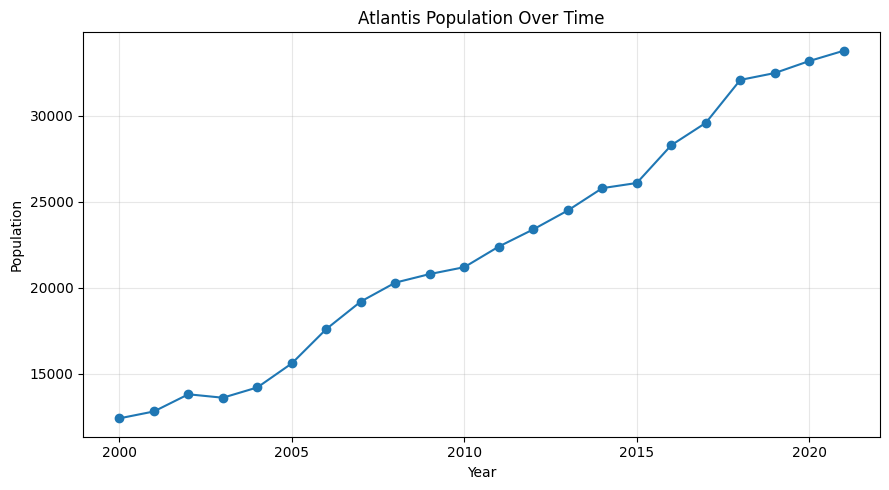

In [22]:
plt.figure(figsize=(9, 5))
plt.plot(population['year'], population['population'], marker='o')
plt.title('Atlantis Population Over Time')
plt.xlabel('Year')
plt.ylabel('Population')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Compare year-to-year changes (5 minutes)

A bar chart makes it easier to compare individual yearly increases. The first year has no annual change, so `.dropna()` leaves it out of this chart. Look for years with relatively larger or smaller increases.

In [ ]:
annual = population.dropna(subset=['annual_change'])
plt.figure(figsize=(10, 5))
plt.bar(annual['year'], annual['annual_change'], color='teal')
plt.title('Annual Population Change in Atlantis')
plt.xlabel('Year')
plt.ylabel('Change in population')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


The charts describe the values in this file. They do not tell us what caused the population changes, and they are not forecasts of future population. A chart can reveal patterns worth investigating, but explaining a cause requires additional evidence.

## 8. Mini-project: tell the data's story (8 minutes)

Use the DataFrame to answer these questions in your own words: Which year has the largest population? How much did the population change between the first and last years? Which year had the largest annual increase? Make one additional chart or adjust a chart to answer a question you are curious about.

Try writing your answers before running the example below.

In [ ]:
largest_population = population.loc[population['population'].idxmax()]
print(f"Largest population: {int(largest_population['population']):,} in {int(largest_population['year'])}")
print(f'Change over the full period: {total_change:,.0f}')
print(f"Largest annual increase: {largest_increase['annual_change']:,.0f} in {int(largest_increase['year'])}")

plt.figure(figsize=(8, 4))
plt.plot(population['year'], population['annual_change_pct'], marker='o', color='darkorange')
plt.title('Year-over-Year Population Change')
plt.xlabel('Year')
plt.ylabel('Change (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Recap

You loaded a CSV into pandas, inspected its structure, checked for missing and duplicated records, filtered and sorted rows, calculated changes over time, and created labeled charts with Matplotlib. Keep asking three questions as you work: What does each row represent? Are the data complete and appropriate for the question? What can this analysis show, and what can it not show?